# Тема 2. Моделирование связи частотного и классического определения вероятности

In [23]:
import scipy.special as sc
import matplotlib.pyplot as plt
import numpy as np
import itertools
import random

Приведите пример, показывающий связь частотного и классического определения вероятности с помощью моделирования (на примере задачи про красно-синие шары или задачи о сумме очков на двух кубиках). Графически показать стремление частотной вероятности к классической при увеличении числа опытов.


## Задача «Случайный плейлист»

В плейлисте находятся **8 разных песен**. Среди них есть две любимые песни — **A** и **B**.
Перед поездкой приложение случайным образом перемешивает все 8 песен. Считается, что все возможные порядки песен равновероятны.
Найти вероятность того, что после случайного перемешивания **две любимые песни окажутся рядом друг с другом**.

### Классический подход

Рассмотрим событие A - две любимые песни A и B окажутся рядом друг с другом.  
$$\mathrm{P}(\mathrm{A})\ =\frac{7!\times 2!}{8!}$$

In [24]:
print(round(sc.factorial(7) * sc.factorial(2) / sc.factorial(8), 4))

0.25


### Частотный подход

Оценим вероятность того, что песни A и B будут рядом друг с другом при $10^6$ перемешиваниях

In [62]:
def random_combination(arr):
    random.shuffle(arr)

count = 10 ** 6
N_values = np.arange(10, count + 1, 10)
playlist = [i for i in "ABCDEFGH"]
N_A = 0

res = []
for N in N_values:
    for i in range(10):
        random_combination(playlist)
        if ("AB" in "".join(playlist)) or ("BA" in "".join(playlist)):
                N_A += 1
    res.append(N_A / N)
res = np.array(res)
print(res)

[0.3        0.35       0.26666667 ... 0.24966399 0.2496655  0.249667  ]


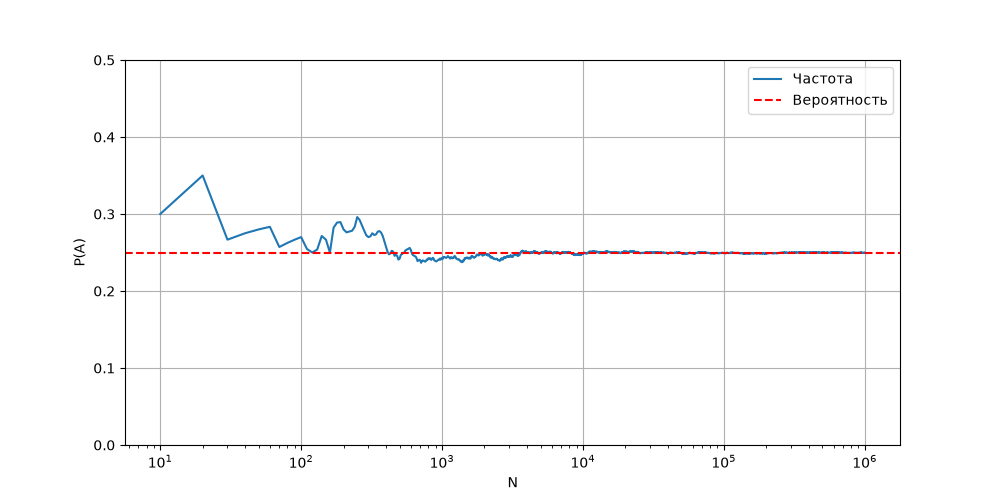

In [67]:
%matplotlib widget
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_xscale("log")
ax.set_ylim(0, 0.5)

ax.plot(N_values, res, label="Частота")
ax.axhline(y=0.25, color='red', linestyle='--', label='Вероятность')
ax.set_xlabel("N")
ax.set_ylabel("P(A)")

ax.grid()
ax.legend()

plt.show()
